# Grand Canyon Conditions

This notebook collects river, reservoir, and weather data useful for viewing recent and historical conditions in the Grand Canyon corridor. It focuses on Colorado River discharge at selected USGS gages, Lake Powell elevation, Lees Ferry water temperature, and Phantom Ranch air temperature.

The notebook produces two main figures:

1. A multi-year daily-values plot showing Colorado River discharge, Lake Powell elevation, and Phantom Ranch / Lees Ferry temperatures.
2. A shorter continuous-values plot showing higher-frequency discharge and water-temperature changes over a selected time window.

The notebook is designed to be rerun so that the daily-values plot can be updated with recent data.

## Data sources

### USGS Water Data

River discharge, Lees Ferry water temperature, and Lake Powell elevation are retrieved using the `waterdata` module from the USGS `dataretrieval` Python package.

This notebook uses:

- `waterdata.get_daily()` for daily values,
- `waterdata.get_continuous()` for higher-frequency continuous values.

The USGS Water Data API returns long/tidy tables with `parameter_code`, `statistic_id`, `time`, and `value` columns. The helper functions in `usgs_io.py` convert those returned tables into time-indexed dataframes suitable for plotting.

Useful USGS links:

- https://doi-usgs.github.io/dataretrieval-python/
- https://help.waterdata.usgs.gov/codes-and-parameters/parameters
- https://waterdata.usgs.gov/
- https://maps.waterdata.usgs.gov/mapper/

### NOAA/NCEI

Phantom Ranch air temperature data are retrieved from NOAA's National Centers for Environmental Information (NCEI), using the GHCN-Daily dataset through the helper module `ncei_io.py`.

The station used here is:

- Phantom Ranch, Arizona: `USC00026471`

Useful NCEI links:

- https://www.ncei.noaa.gov/
- https://www.ncei.noaa.gov/cdo-web/search?datasetid=GHCND

In [13]:
# Run this cell first when using Google Colab.

import os
import sys
from pathlib import Path

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ

if IN_COLAB:
    %cd /content

    if not Path("rivers").exists():
        !git clone -q https://github.com/gregorywanderson/rivers.git

    %cd /content/rivers/grand_canyon
    !pip install -q dataretrieval pandas matplotlib requests

# Make parent directory importable so notebooks can find ncei_io.py and usgs_io.py.
sys.path.insert(0, str(Path.cwd().parent))

In [ ]:
# Standard library
import datetime as dt
import importlib
import sys
from pathlib import Path

# Third party
import matplotlib.pyplot as plt
import pandas as pd
from dataretrieval import waterdata

# Local path setup
sys.path.insert(0, str(Path.cwd().parent))

# Local
import ncei_io as ncei
import usgs_io as usgs

try:
    import my_trips
except ModuleNotFoundError:
    my_trips = None

importlib.reload(ncei)
importlib.reload(usgs)

if my_trips is not None:
    importlib.reload(my_trips)

In [ ]:
# ---------------------------------------------------------------------
# Analysis windows
# ---------------------------------------------------------------------

TZ = "America/Phoenix"

def local_timestamp(date_string, tz=TZ):
    """Convert YYYY-MM-DD string to a timezone-aware pandas Timestamp."""
    return pd.Timestamp(date_string, tz=tz)

# Use today's date in the local Grand Canyon / Arizona time zone.
TODAY = pd.Timestamp.now(tz=TZ).strftime("%Y-%m-%d")

# Daily values often lag or may be incomplete for the current day.
# Use TODAY for the most current possible result, or use YESTERDAY
# for a more conservative fully completed daily-value window.
YESTERDAY = (
    pd.Timestamp.now(tz=TZ) - pd.Timedelta(days=1)
).strftime("%Y-%m-%d")

# Long-window daily-value plot.
DV_START_DATE = "2020-01-01"
DV_END_DATE = YESTERDAY

# Short-window instantaneous-value plot.
IV_START_DATE = "2025-06-01"
IV_END_DATE = "2025-06-08"

DV_START = local_timestamp(DV_START_DATE)
DV_END = local_timestamp(DV_END_DATE)

IV_START = local_timestamp(IV_START_DATE)
IV_END = local_timestamp(IV_END_DATE)

# Optional: set to True if a local my_trips.py file is available.
SHOW_TRIPS = False # 

In [3]:
def ensure_phoenix_index(df):
    """
    Ensure a DataFrame has a timezone-aware DatetimeIndex in America/Phoenix.

    Rules:
    - If the index is timezone-naive (typical for NWIS 'dv'):
      → interpret timestamps as local Arizona time (MST, no DST)
    - If the index is timezone-aware (typical for NWIS 'iv'):
      → convert to America/Phoenix
    """
    df = df.copy()
    idx = df.index

    if not isinstance(idx, pd.DatetimeIndex):
        raise TypeError("DataFrame index must be a DatetimeIndex")

    if idx.tz is None:
        # DV-style: dates or naive datetimes represent local AZ time
        df.index = idx.tz_localize("America/Phoenix")
    else:
        # IV-style: typically UTC → convert to AZ time
        df.index = idx.tz_convert("America/Phoenix")

    return df


In [4]:
# Daily Summaries for mas/min/ave temp, precipitation, ...
# this cell can take a few minutes to run
met_pr = ncei.get_ghcnd_daily_summaries(
    station_id="USC00026471",   # or pick from search results
    start_date=DV_START_DATE,
    end_date=DV_END_DATE,
    data_types=["TMAX", "TMIN", "TAVG","PRCP"],
)
met_pr.columns

Index(['STATION', 'NAME', 'PRCP', 'TAVG', 'TMAX', 'TMIN', 'DATE'], dtype='str')

#### Selected USGS parameter codes and statistic IDs

USGS Water Data identifies observations using both a `parameter_code` and a `statistic_id`.

Selected parameter codes:

| Quantity | Parameter code |
|---|---:|
| Water temperature (°C) | `00010` |
| Air temperature (°C) | `00020` |
| Discharge (ft³/s) | `00060` |
| Gage height (ft) | `00065` |
| Lake / reservoir elevation, NGVD 1929 (ft) | `62614` |
| Lake / reservoir elevation, NAVD 1988 (ft) | `62615` |
| Turbidity (FNU) | `63820` |

Selected statistic IDs:

| Statistic | Statistic ID |
|---|---:|
| Maximum | `00001` |
| Minimum | `00002` |
| Mean | `00003` |
| Instantaneous / continuous observation | `00011` |

For a full list of USGS parameter codes, see:

https://help.waterdata.usgs.gov/codes-and-parameters/parameters

In [5]:
# USGS parameter codes
DISCHARGE = "00060"
WATER_TEMPERATURE = "00010"
AIR_TEMPERATURE = "00020"
RESERVOIR_ELEVATION = "62615"

# USGS statistic IDs
MAXIMUM   = "00001"
MINIMUM   = "00002"
MEAN      = "00003"
INSTANTANEOUS = "00011"

HYDROPOWER_CUTOFF = 3490 # Hydropower cutoff for Lake Powell
DEAD_POOL = 3370         # Water can't pass through the outlets at Lake Powell

### Selected USGS site numbers

In [ ]:
# Reservoirs: the Bureau of Reclamation is the definitive source
# for reservoir operations data.

LAKE_POWELL = "USGS-09379900"

CR_LEES_FERRY = "USGS-09380000"
CR_61 = "USGS-09383100"
CR_KAIBAB = "USGS-09402500"
CR_ABV_SUPAI = "USGS-09404120"
CR_DIAMOND_CREEK = "USGS-09404200"

PR = "USGS-09402000"
LC = "USGS-09402300"
KC = "USGS-09403600"
HC = "USGS-09403013"

For a complete list see 
  - https://waterdata.usgs.gov/nwis/inventory or 
  - https://maps.waterdata.usgs.gov/mapper/index.html

## Daily Values

In [ ]:
# DailyLake Level
dv_lp, md_lp = waterdata.get_daily(
    monitoring_location_id=LAKE_POWELL,
    parameter_code=RESERVOIR_ELEVATION, # Lake Powell water level
    statistic_id=MEAN, 
    time=f"{DV_START_DATE}/{DV_END_DATE}",
)

dv_lp = usgs.wrangle_waterdata_timeseries(
    dv_lp,
    value_name="elevation_ft",
    tz=TZ,
)
dv_lp.head()

,geometry,time_series_id,monitoring_location_id,parameter_code,statistic_id,elevation_ft,unit_of_measure,approval_status,qualifier,last_modified,daily_id
time,,,,,,,,,,,
2020-01-01 00:00:00-07:00,POINT (-111.48405 36.93665),a1ac1fb483a748e98e53da30676756d4,USGS-09379900,62615,00003,3611.2,ft,Approved,None,2025-03-11 21:42:56.796363+00:00,d370bb5f-c340-42d4-86bd-50f71cfde229
2020-01-02 00:00:00-07:00,POINT (-111.48405 36.93665),a1ac1fb483a748e98e53da30676756d4,USGS-09379900,62615,00003,3611.1,ft,Approved,None,2025-03-11 21:42:56.796363+00:00,3cabd323-cf90-477f-8a60-07f3f098fb8b
2020-01-03 00:00:00-07:00,POINT (-111.48405 36.93665),a1ac1fb483a748e98e53da30676756d4,USGS-09379900,62615,00003,3611.0,ft,Approved,None,2025-03-11 21:42:56.796363+00:00,326f83d4-77df-481a-a253-d09dc9a558a1
2020-01-04 00:00:00-07:00,POINT (-111.48405 36.93665),a1ac1fb483a748e98e53da30676756d4,USGS-09379900,62615,00003,3610.9,ft,Approved,None,2025-03-11 21:42:56.796363+00:00,2a302c57-5a83-4ed4-a4da-b8bf1cf0fd07
2020-01-05 00:00:00-07:00,POINT (-111.48405 36.93665),a1ac1fb483a748e98e53da30676756d4,USGS-09379900,62615,00003,3610.8,ft,Approved,None,2025-03-11 21:42:56.796363+00:00,fe9e5e3e-bfa2-446c-9873-ff20c383c2bc


In [8]:
# Daily discharge on the Colorado River
# Lees Ferry also includes daily water temperature.

dv_lf, md_lf = waterdata.get_daily(
    monitoring_location_id=CR_LEES_FERRY,
    parameter_code=[DISCHARGE, WATER_TEMPERATURE],
    statistic_id=MEAN,
    time=f"{DV_START_DATE}/{DV_END_DATE}",
)

dv_lf = usgs.wrangle_waterdata_timeseries(dv_lf, tz=TZ)

dv_lf = usgs.waterdata_to_wide(
    dv_lf,
    names={
        (DISCHARGE, MEAN): "discharge_cfs",
        (WATER_TEMPERATURE, MEAN): "water_temperature_c",
    },
)


dv_k, md_k = waterdata.get_daily(
    monitoring_location_id=CR_KAIBAB,
    parameter_code=DISCHARGE,
    statistic_id=MEAN,
    time=f"{DV_START_DATE}/{DV_END_DATE}",
)

dv_k = usgs.wrangle_waterdata_timeseries(dv_k, tz=TZ)

dv_k = usgs.waterdata_to_wide(
    dv_k,
    names={
        (DISCHARGE, MEAN): "discharge_cfs",
    },
)


dv_d, md_d = waterdata.get_daily(
    monitoring_location_id=CR_DIAMOND_CREEK,
    parameter_code=DISCHARGE,
    statistic_id=MEAN,
    time=f"{DV_START_DATE}/{DV_END_DATE}",
)

dv_d = usgs.wrangle_waterdata_timeseries(dv_d, tz=TZ)

dv_d = usgs.waterdata_to_wide(
    dv_d,
    names={
        (DISCHARGE, MEAN): "discharge_cfs",
    },
)

### Plot Daily Values

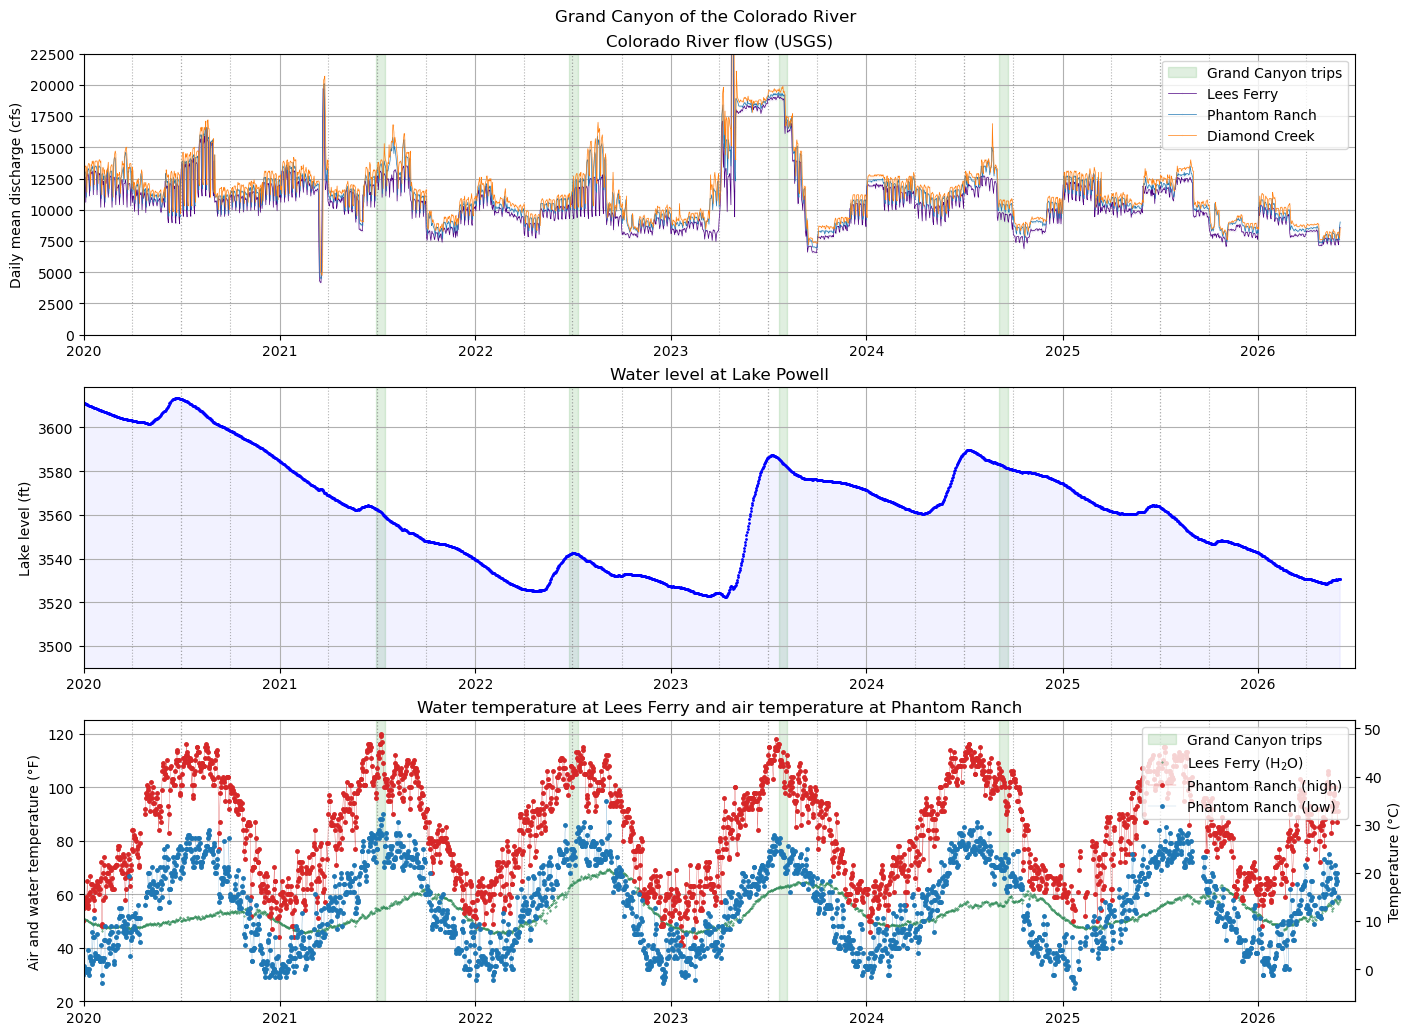

In [ ]:
# Plot daily values for multiple years

DV_START = pd.Timestamp(DV_START_DATE, tz=TZ)
DV_END = pd.Timestamp(DV_END_DATE, tz=TZ)

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(14, 10), constrained_layout=True
)

fig.suptitle("Grand Canyon of the Colorado River", y=1.02)

axes = (ax1, ax2, ax3)

# Quarter and midyear vertical reference lines.
years = range(DV_START.year, DV_END.year + 1)

for year in years:
    q1_end = pd.Timestamp(f"{year}-04-01", tz=TZ)
    midyear = pd.Timestamp(f"{year}-07-01", tz=TZ)
    q4_begin = pd.Timestamp(f"{year}-10-01", tz=TZ)

    for ax in axes:
        if DV_START <= q1_end <= DV_END:
            ax.axvline(
                q1_end,
                linestyle=":",
                linewidth=0.8,
                alpha=0.6,
                color="gray",
            )

        if DV_START <= midyear <= DV_END:
            ax.axvline(
                midyear,
                linestyle=":",
                linewidth=0.9,
                alpha=0.7,
                color="gray",
            )

        if DV_START <= q4_begin <= DV_END:
            ax.axvline(
                q4_begin,
                linestyle=":",
                linewidth=0.8,
                alpha=0.6,
                color="gray",
            )

if SHOW_TRIPS:
    for ax in axes:
        my_trips.add_trip_spans(ax, tz=TZ, alpha=0.12)

# ---------------------------------------------------------------------
# Daily mean discharge
# ---------------------------------------------------------------------

ax1.grid(True)
ax1.axis([DV_START, DV_END, 0, 22500])
ax1.set_ylabel("Daily mean discharge (cfs)")
ax1.set_title("Colorado River flow (USGS)")

ax1.plot(
    dv_lf.index,
    dv_lf["discharge_cfs"],
    color="indigo",
    linestyle="solid",
    marker="o",
    markersize=0.02,
    label="Lees Ferry",
    linewidth=0.5,
)

ax1.plot(
    dv_k.index,
    dv_k["discharge_cfs"],
    color="tab:blue",
    linestyle="solid",
    marker="o",
    markersize=0.02,
    label="Phantom Ranch",
    linewidth=0.5,
)

ax1.plot(
    dv_d.index,
    dv_d["discharge_cfs"],
    color="tab:orange",
    linestyle="solid",
    marker="o",
    markersize=0.02,
    label="Diamond Creek",
    linewidth=0.5,
)

ax1.legend()

# ---------------------------------------------------------------------
# Lake Powell water level
# ---------------------------------------------------------------------

ax2.grid(True)
ax2.axis(
    [
        DV_START,
        DV_END,
        HYDROPOWER_CUTOFF,
        dv_lp["elevation_ft"].max() + 5,
    ]
)

ax2.fill_between(
    dv_lp.index,
    dv_lp["elevation_ft"],
    color="blue",
    alpha=0.05,
)

ax2.plot(
    dv_lp.index,
    dv_lp["elevation_ft"],
    color="blue",
    linestyle="none",
    marker="o",
    markersize=1,
    linewidth=1,
)

ax2.set_ylabel("Lake level (ft)")
ax2.set_title("Water level at Lake Powell")

# ---------------------------------------------------------------------
# Air and water temperature
# ---------------------------------------------------------------------

ax3.axis([DV_START, DV_END, 20, 125])
ax3.grid(True)

ax3.plot(
    dv_lf.index,
    9 * dv_lf["water_temperature_c"] / 5 + 32,
    color="seagreen",
    linestyle="none",
    marker="o",
    markersize=0.4,
    label="Lees Ferry (H${}_2$O)",
    linewidth=0.5,
)

ax3.plot(
    met_pr["DATE"],
    met_pr["TMAX"],
    color="tab:red",
    linestyle="solid",
    marker="o",
    markersize=2.5,
    label="Phantom Ranch (high)",
    linewidth=0.2,
)

ax3.plot(
    met_pr["DATE"],
    met_pr["TMIN"],
    color="tab:blue",
    linestyle="solid",
    marker="o",
    markersize=2.5,
    label="Phantom Ranch (low)",
    linewidth=0.1,
)

ax3.legend()

ax3.set_ylabel("Air and water temperature (°F)")
ax3.set_title(
    "Water temperature at Lees Ferry and air temperature at Phantom Ranch"
)

ax3_secondary = ax3.secondary_yaxis(
    "right",
    functions=(
        lambda temp_f: (temp_f - 32) * 5 / 9,
        lambda temp_c: temp_c * 9 / 5 + 32,
    ),
)

ax3_secondary.set_ylabel("Temperature (°C)")

plt.savefig("figures/gc_conditions.pdf")
plt.savefig("figures/gc_conditions.png")
plt.show()

## Continuous Values

In [10]:
# Continuous discharge on the Colorado River
# Lees Ferry also includes water temperature.

iv_lf, md_iv_lf = waterdata.get_continuous(
    monitoring_location_id=CR_LEES_FERRY,
    parameter_code=[DISCHARGE, WATER_TEMPERATURE],
    time=f"{IV_START_DATE}/{IV_END_DATE}",
)

iv_lf = usgs.wrangle_waterdata_timeseries(iv_lf, tz=TZ)

iv_lf = usgs.waterdata_to_wide(
    iv_lf,
    names={
        (DISCHARGE, INSTANTANEOUS): "discharge_cfs",
        (WATER_TEMPERATURE, INSTANTANEOUS): "water_temperature_c",
    },
)


iv_k, md_iv_k = waterdata.get_continuous(
    monitoring_location_id=CR_KAIBAB,
    parameter_code=DISCHARGE,
    time=f"{IV_START_DATE}/{IV_END_DATE}",
)

iv_k = usgs.wrangle_waterdata_timeseries(iv_k, tz=TZ)

iv_k = usgs.waterdata_to_wide(
    iv_k,
    names={
        (DISCHARGE, INSTANTANEOUS): "discharge_cfs",
    },
)


iv_d, md_iv_d = waterdata.get_continuous(
    monitoring_location_id=CR_DIAMOND_CREEK,
    parameter_code=DISCHARGE,
    time=f"{IV_START_DATE}/{IV_END_DATE}",
)

iv_d = usgs.wrangle_waterdata_timeseries(iv_d, tz=TZ)

iv_d = usgs.waterdata_to_wide(
    iv_d,
    names={
        (DISCHARGE, INSTANTANEOUS): "discharge_cfs",
    },
)

### Plot Continuous Values

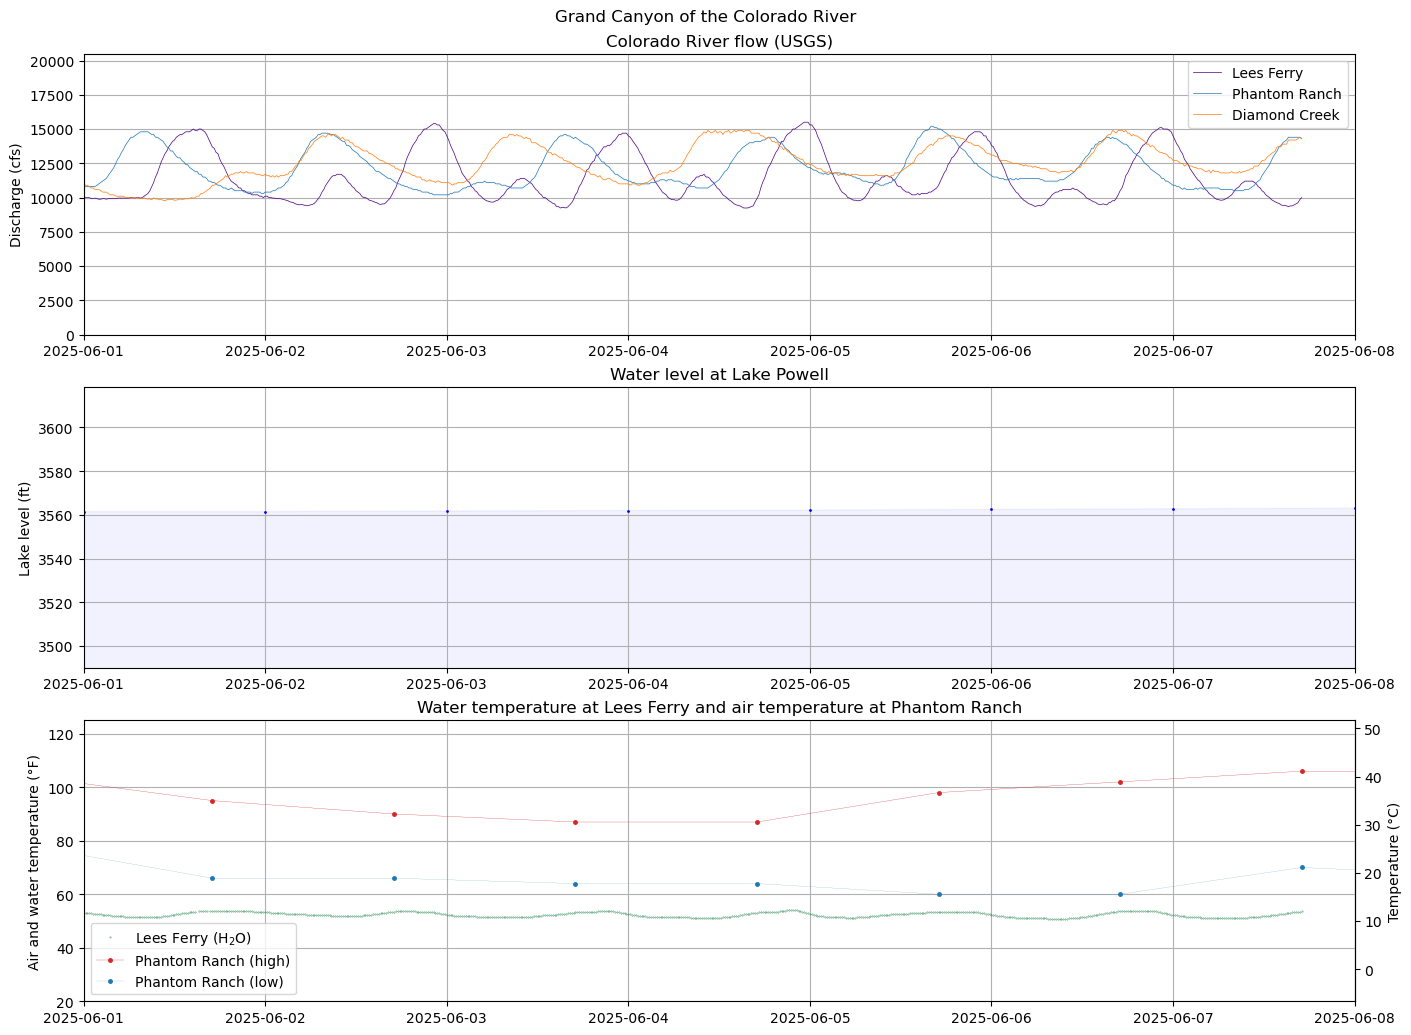

In [11]:
# Plot instantaneous values

IV_START = pd.Timestamp(IV_START_DATE, tz=TZ)
IV_END = pd.Timestamp(IV_END_DATE, tz=TZ)

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(14, 10), constrained_layout=True
)

fig.suptitle("Grand Canyon of the Colorado River", y=1.02)

# ---------------------------------------------------------------------
# Instantaneous discharge
# ---------------------------------------------------------------------

ax1.grid(True)
ax1.axis([IV_START, IV_END, 0, 20500])
ax1.set_ylabel("Discharge (cfs)")
ax1.set_title("Colorado River flow (USGS)")

ax1.plot(
    iv_lf.index,
    iv_lf["discharge_cfs"],
    color="indigo",
    linestyle="solid",
    marker="o",
    markersize=0.02,
    label="Lees Ferry",
    linewidth=0.5,
)

ax1.plot(
    iv_k.index,
    iv_k["discharge_cfs"],
    color="tab:blue",
    linestyle="solid",
    marker="o",
    markersize=0.02,
    label="Phantom Ranch",
    linewidth=0.5,
)

ax1.plot(
    iv_d.index,
    iv_d["discharge_cfs"],
    color="tab:orange",
    linestyle="solid",
    marker="o",
    markersize=0.02,
    label="Diamond Creek",
    linewidth=0.5,
)

ax1.legend()

# ---------------------------------------------------------------------
# Lake Powell water level
# ---------------------------------------------------------------------

ax2.grid(True)
ax2.axis(
    [
        IV_START,
        IV_END,
        HYDROPOWER_CUTOFF,
        dv_lp["elevation_ft"].max() + 5,
    ]
)

ax2.fill_between(
    dv_lp.index,
    dv_lp["elevation_ft"],
    color="blue",
    alpha=0.05,
)

ax2.plot(
    dv_lp.index,
    dv_lp["elevation_ft"],
    color="blue",
    linestyle="none",
    marker="o",
    markersize=1,
    linewidth=1,
)

ax2.set_ylabel("Lake level (ft)")
ax2.set_title("Water level at Lake Powell")

# ---------------------------------------------------------------------
# Air and water temperature
# ---------------------------------------------------------------------

ax3.axis([IV_START, IV_END, 20, 125])
ax3.grid(True)

ax3.plot(
    iv_lf.index,
    9 * iv_lf["water_temperature_c"] / 5 + 32,
    color="seagreen",
    linestyle="none",
    marker="o",
    markersize=0.3,
    label="Lees Ferry (H${}_2$O)",
    linewidth=0.2,
)

ax3.plot(
    met_pr["DATE"],
    met_pr["TMAX"],
    color="tab:red",
    linestyle="solid",
    marker="o",
    markersize=2.5,
    label="Phantom Ranch (high)",
    linewidth=0.2,
)

ax3.plot(
    met_pr["DATE"],
    met_pr["TMIN"],
    color="tab:blue",
    linestyle="solid",
    marker="o",
    markersize=2.5,
    label="Phantom Ranch (low)",
    linewidth=0.1,
)

ax3.legend()

ax3.set_ylabel("Air and water temperature (°F)")
ax3.set_title(
    "Water temperature at Lees Ferry and air temperature at Phantom Ranch"
)

ax3_secondary = ax3.secondary_yaxis(
    "right",
    functions=(
        lambda temp_f: (temp_f - 32) * 5 / 9,
        lambda temp_c: temp_c * 9 / 5 + 32,
    ),
)

ax3_secondary.set_ylabel("Temperature (°C)")

plt.savefig("figures/gc_conditions2.pdf")
plt.savefig("figures/gc_conditions2.png")
plt.show()